# E3 — ISIC 2017 UNet2D LR-Schedule Tie-Break (10 seeds)

**Question.** With the architecture and learning rate already fixed (`classical + attention_gate`, `lr = 3e-4`), does the **LR decay schedule** change the model? We compare cosine annealing against ReduceLROnPlateau head-to-head.

**Design.** 10 shared seeds (100–109). Within each seed both schedulers share weight initialisation and data ordering, so the *only* difference inside a seed pair is the schedule. We analyse the **paired** differences Δᵢ = cosineᵢ − plateauᵢ on the ISIC 2017 validation set.

**Source.** `E3-isic2017-unet2d-cosanneal-10seeds.db` + `E3-isic2017-unet2d-reduceonplateauON-10seeds.db` — 20 runs (2 schedules × 10 seeds), all `FINISHED`.

> **Scope.** This compares two *decay* schedules against each other. A 1-seed pilot found no quality difference between cosine and flat LR, so the scheduler was dropped before E4. A post-hoc unpaired comparison (E3 cosine vs E4 flat LR, 10 seeds each) on plateau Dice suggests cosine is better (Δ=+0.0042, BCa 95% CI [+0.0015, +0.0069]); the 1-seed pilot was underpowered. See Decision for caveats.

## Executive summary

- Paired across 10 shared seeds, Δ = cosine − plateau
- Primary test = Wilcoxon signed-rank
- CI = BCa bootstrap 95 % (10 000 resamples, `rng=42`)
- d_z = Cohen's paired effect size.

| Metric | Cosine | Plateau | Δ (cos−plat) | 95 % BCa CI | Wilcoxon p | d_z | Verdict |
|---|---|---|---|---|---|---|---|
| **Plateau Dice** — *primary* [1] | 0.8346 | 0.8331 | +0.0015 | [−0.0006, +0.0038] | 0.32 | +0.38 | tie |
| Peak Dice | 0.8451 | 0.8459 | −0.0007 | [−0.0024, +0.0006] | 0.43 | −0.29 | tie |
| Peak IoU | 0.7382 | 0.7392 | −0.0010 | [−0.0033, +0.0008] | 0.43 | −0.29 | tie |
| Generalisation gap *(lower = better)* | 0.0957 | 0.0971 | −0.0014 | [−0.0054, +0.0039] | 0.70 | −0.18 | tie |
| Throughput | 119.4 sps | 118.9 sps | +0.5 (+0.4 %) | [−1.7, +4.8] | 0.85 | +0.09 | tie |

[1] Plateau Dice (last-10-epoch mean) is the primary quality metric; tested standalone (k = 1, α = 0.05). Secondary quality metrics (Peak Dice, Peak IoU, gen-gap) form a Holm family (k = 3).

**Finding.**
- **No metric reaches significance.** Every Wilcoxon p ≥ 0.32, every BCa CI straddles 0, every |d_z| ≤ 0.38 (negligible–small). The two schedules are statistically indistinguishable on all quality and cost axes.
- The only consistent difference is **convergence timing, not quality**: cosine reaches its best checkpoint at epoch 125 on average vs 161 for plateau (≈ 36 epochs / ~22 % earlier), at equal throughput.

**Decision: between the two decay schedules, prefer `cosine_annealing`** — not on Dice (a tie) but on earlier, deterministic convergence. The decay-vs-no-decay question stays open pending the flat-LR baseline.

In [7]:
# ── Path bootstrap (must run before any SkiNet import) ───────────────────────
import sys
from pathlib import Path

# Resolve the repo root regardless of kernel working directory.
# VS Code injects __vsc_ipynb_file__; nbconvert sets CWD = notebook directory.
try:
    _nb_dir = Path(__vsc_ipynb_file__).resolve().parent  # VS Code interactive
except NameError:
    _nb_dir = Path().resolve()                            # nbconvert / CLI

PROJECT_ROOT = _nb_dir.parents[1].resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

from SkiNet.Utils.analysis.aggregation import load_runs
from SkiNet.Utils.analysis.stats import build_comparison_table
from SkiNet.Utils.analysis.reporting import show_run_table, show_comparison_table, show_family_verdicts
from SkiNet.Utils.analysis.plotting import set_paper_style, plot_paired_slopegraph, plot_paired_forest
from SkiNet.Utils.analysis.schema import VAL_DICE_MAX, VAL_DICE_TAIL_MEAN, VAL_IOU_MAX, GENERALIZATION_GAP_FINAL, SAMPLES_PER_SEC

# ── Configuration — every tunable argument lives in this cell ────────────────
FIG_DIR  = _nb_dir / '_static/model_selection'
# Each scheduler arm was logged to its own MLflow DB (both use experiment_id=1
# internally), so we load and label them separately, then concatenate.
DB_DIR   = PROJECT_ROOT / 'mlruns'
COS_DB   = DB_DIR / 'E3-isic2017-unet2d-cosanneal-10seeds.db'             # seeds 100–109
PLAT_DB  = DB_DIR / 'E3-isic2017-unet2d-reduceonplateauON-10seeds.db'     # seeds 100–109

COSINE, PLATEAU = 'cosine_annealing', 'reduce_on_plateau'
PALETTE = {COSINE: '#d1495b', PLATEAU: '#30638e'}  # color palette for the two schedules

ALPHA   = 0.05      # significance level for confidence intervals and hypothesis tests
N_BOOT  = 10_000    # bootstrap samples for confidence intervals and p-values
RNG     = np.random.default_rng(42)  # random number generator for reproducibility

# Metric column names are imported from SkiNet.Utils.analysis.schema; the spec
# lists below stay here because the choice of metrics, family sizes and display
# names is specific to this E3 paired comparison.
PRIMARY_METRIC    = VAL_DICE_TAIL_MEAN
SECONDARY_METRICS = [VAL_DICE_MAX, VAL_IOU_MAX, GENERALIZATION_GAP_FINAL]
# (metric, higher_is_better, family_size_k)
METRICS_SPEC = [
    (VAL_DICE_MAX,             True,  len(SECONDARY_METRICS)),
    (VAL_IOU_MAX,              True,  len(SECONDARY_METRICS)),
    (VAL_DICE_TAIL_MEAN,       True,  1),
    (GENERALIZATION_GAP_FINAL, False, len(SECONDARY_METRICS)),
    (SAMPLES_PER_SEC,          True,  1),
]
SLOPE_METRICS = [
    (VAL_DICE_MAX,       'Peak Dice (best checkpoint)'),
    (VAL_DICE_TAIL_MEAN, 'Plateau Dice (last-10-epoch mean)'),
]
# (display_name, metric, higher_is_better)
FOREST_SPECS = [
    ('Peak Dice',         VAL_DICE_MAX,             False),
    ('Peak IoU',          VAL_IOU_MAX,              False),
    ('Plateau Dice',      VAL_DICE_TAIL_MEAN,       False),
    ('Gen-gap reduction', GENERALIZATION_GAP_FINAL, True),
]

# ── Presentation ─────────────────────────────────────────────────────────────
set_paper_style(context='notebook')
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.4f}'.format)

In [8]:
# ── Load: 20 runs = 2 schedules × 10 seeds ───────────────────────────────────
# Both DBs use experiment_id=1, so each is loaded with its own one-entry exp_map
# and the labelled frames are concatenated into the paired (seed × schedule) table.
runs = pd.concat([
    load_runs(COS_DB,  exp_map={1: COSINE},  monitor='val_dice'),
    load_runs(PLAT_DB, exp_map={1: PLATEAU}, monitor='val_dice'),
], ignore_index=True)
SEEDS, N = sorted(runs['seed'].unique()), runs['seed'].nunique()

Loaded 10 runs: {'cosine_annealing': 10} | seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
Loaded 10 runs: {'reduce_on_plateau': 10} | seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]


## 1. Data

One row per (seed, schedule). Columns:

- **`val_dice_max`** — peak Dice of the best-saved checkpoint (the model that would actually be deployed).
- **`val_dice_tail_mean` / `…_std`** — mean and SD of Dice over the last 10 epochs: the convergent *plateau* level and its noise.
- **`val_dice_max_epoch`** — epoch at which the best checkpoint was reached (convergence-speed signal).
- **`val_iou_max`** — peak IoU of the best checkpoint.
- **`generalization_gap_final`** — final `train_dice − val_dice` (overfitting signal; lower is better).
- **`samples_per_sec` / `duration_min`** — training throughput and wall-clock cost.

In [9]:
show_run_table(runs)

,arch,seed,val_dice_max,val_dice_tail_mean,val_dice_tail_std,val_iou_max,generalization_gap_final,samples_per_sec,duration_min
0,cosine_annealing,100,0.8444,0.8384,0.0020,0.7374,0.0944,119.8566,47.3305
1,cosine_annealing,101,0.8475,0.8385,0.0011,0.7410,0.0902,115.3991,45.7549
2,cosine_annealing,102,0.8443,0.8366,0.0020,0.7372,0.0943,115.9677,45.7975
3,cosine_annealing,103,0.8474,0.8389,0.0020,0.7409,0.0887,116.6589,45.6267
4,cosine_annealing,104,0.8476,0.8323,0.0008,0.7413,0.1000,118.5947,45.8264
5,cosine_annealing,105,0.8473,0.8322,0.0021,0.7409,0.0923,119.3180,45.6379
6,cosine_annealing,106,0.8413,0.8292,0.0013,0.7335,0.1028,121.5028,45.7030
7,cosine_annealing,107,0.8438,0.8326,0.0012,0.7379,0.0971,118.5776,45.7078
8,cosine_annealing,108,0.8431,0.8352,0.0018,0.7342,0.0977,129.1880,45.7106
9,cosine_annealing,109,0.8447,0.8317,0.0016,0.7377,0.0994,118.5783,45.7795


## 2. Statistical methods

### 2.1 Paired design

Within each seed, cosine and plateau share weight initialisation and data ordering, so everything that varies run-to-run **except the schedule** is held constant. Subtracting within the pair, Δᵢ = cosineᵢ − plateauᵢ, removes seed-to-seed noise and we analyse 10 paired differences.

> **Scope caveat.** All seeds reuse a single fixed ISIC-2017 train/validation split; only initialisation varies — this is *not* k-fold cross-validation. Per Rainio et al. (2024), fixed-split p-values can understate variance, so treat every interval and p-value below as an **optimistic lower bound** on the true uncertainty. (For a null result this cuts the safe way: even the optimistic intervals fail to separate the schedules.)

### 2.2 Hypothesis families

Each family controls its own family-wise error rate at α = 0.05.

| Family | Metric(s) | k | Per-metric threshold | Correction |
|---|---|---|---|---|
| **Primary** | `val_dice_tail_mean` | 1 | **0.05** | none |
| **Secondary quality** | `val_dice_max`, `val_iou_max`, gen-gap | 3 | ≤ **0.0167** | Holm step-down |
| **Training cost** | `samples_per_sec` | 1 | **0.05** | none |

*Why plateau Dice is primary:* it measures the **stable, convergent** Dice level (mean of the last 10 epochs) — the quantity a schedule is supposed to improve — rather than a lucky single-epoch peak.

### 2.3 Inference criteria

Three complementary statistics on the same 10 paired differences — identical to the E2 tie-break (Wilcoxon signed-rank, BCa bootstrap 95 % CI, Cohen's d_z); see E2 §2.3 for the full derivation. At n = 10 the smallest achievable two-tailed Wilcoxon p is 2 / 2¹⁰ = **0.00195**, so the test has room to reject if a real effect existed.

## 3. Results

In [10]:
results = build_comparison_table(
    runs, METRICS_SPEC,
    arch_a=COSINE, arch_b=PLATEAU, seeds=SEEDS,
    alpha=ALPHA, n_resamples=N_BOOT, random_state=RNG,
)
show_comparison_table(results, label_a='cosine', label_b='plateau')
show_family_verdicts(results, PRIMARY_METRIC, SECONDARY_METRICS, alpha=ALPHA)

,cosine,plateau,Δ (cosine−plateau),95% BCa CI,wilcoxon_p,sig,d_z
val_dice_max,0.8451,0.8459,-0.0007,"[-0.0024, +0.0006]",0.4316,,-0.2900
val_iou_max,0.7382,0.7392,-0.0010,"[-0.0033, +0.0008]",0.4316,,-0.2900
val_dice_tail_mean,0.8346,0.8331,+0.0015,"[-0.0006, +0.0038]",0.3223,,0.3800
generalization_gap_final,0.0957,0.0971,-0.0014,"[-0.0054, +0.0039]",0.6953,,-0.1800
samples_per_sec,119.3642,118.9131,+0.4511,"[-1.6984, +4.7605]",0.8457,,0.0900


Primary  val_dice_tail_mean  (k=1, α=0.05):
  p=0.3223  →  retain H0

Holm step-down  secondary family  (k=3, α_adj=0.0167):
                              p  threshold  reject
test                                              
val_dice_max             0.4316     0.0167   False
val_iou_max              0.4316     0.0250   False
generalization_gap_final 0.6953     0.0500   False

Throughput  samples_per_sec  (k=1, α=0.05):
  p=0.8457  →  retain H0


## 4. Figures

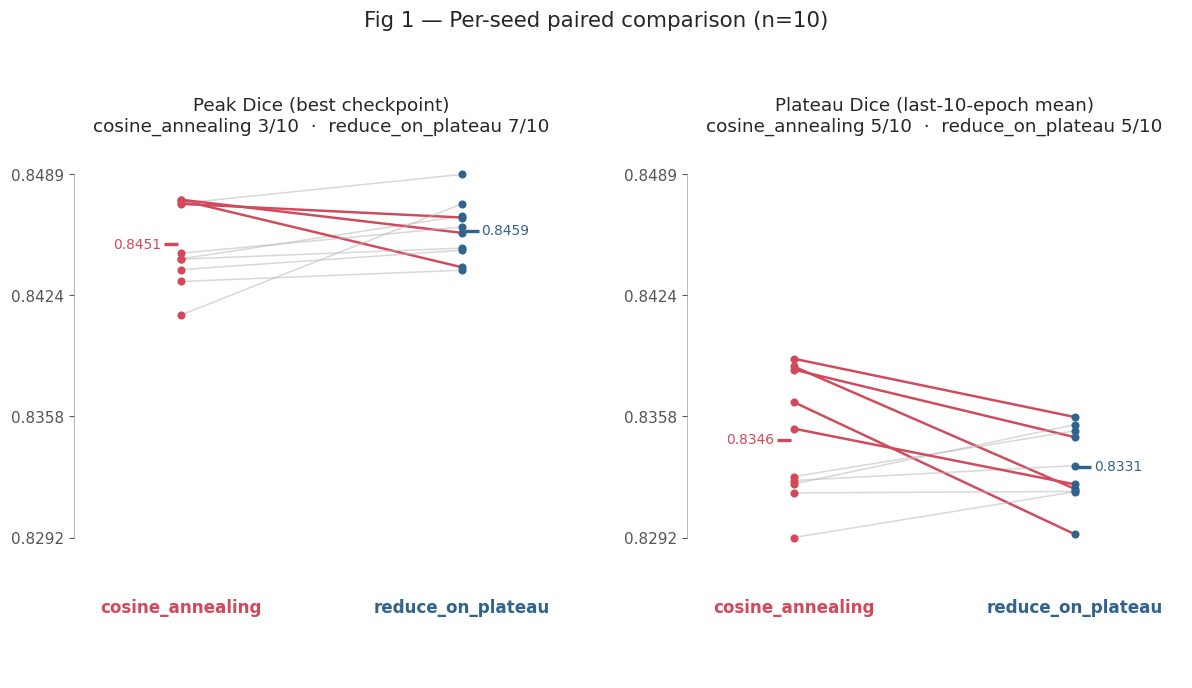

In [11]:
plot_paired_slopegraph(
    runs, SLOPE_METRICS,
    arch_a=COSINE, arch_b=PLATEAU, seeds=SEEDS, palette=PALETTE,
    title=f'Fig 1 — Per-seed paired comparison (n={N})',
    save_path=FIG_DIR / 'E3_fig1_paired_slopegraph.png',
);

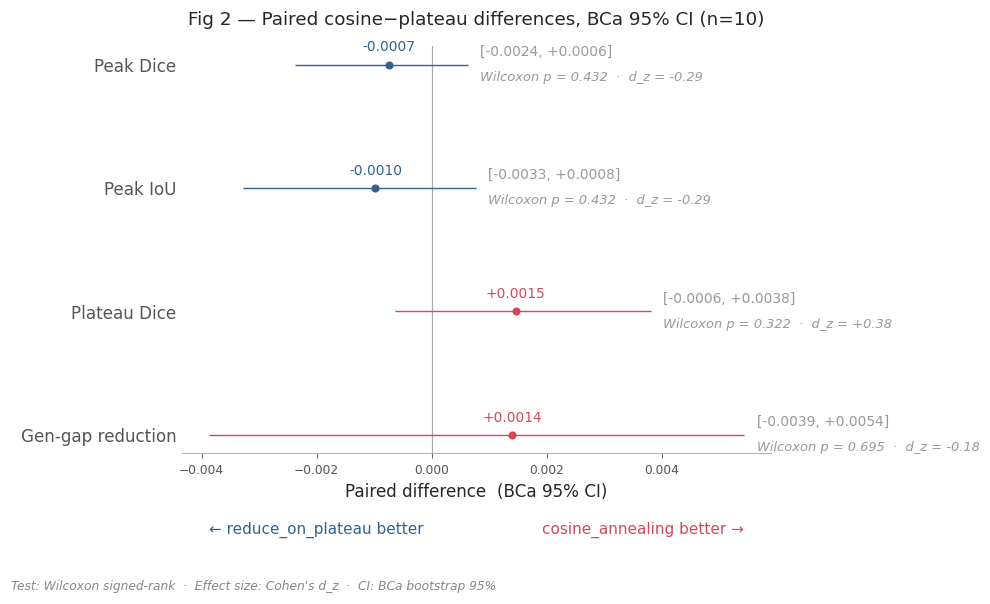

In [12]:
plot_paired_forest(
    results, FOREST_SPECS,
    arch_a=COSINE, arch_b=PLATEAU, n=N, palette=PALETTE,
    title=f'Fig 2 — Paired cosine−plateau differences, BCa 95% CI (n={N})',
    save_path=FIG_DIR / 'E3_fig2_forest_paired_diff.png',
);

## 4b. Post-hoc: cosine annealing vs flat LR (unpaired)

E4 used flat LR (`use_lr_scheduler: false`) based on a 1-seed pilot. This is an unpaired comparison of E3 cosine (10 seeds) against E4 flat LR (10 seeds, same architecture and lr=3e-4, different experiment). Seeds are the same numbers (100–109) but runs were independent, so differences are unpaired. The strip plot shows the two distributions; the forest plot shows the mean difference with BCa 95 % CI.

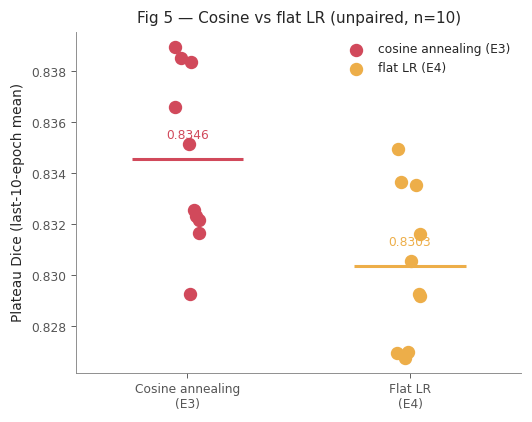

In [13]:
import sqlite3, re as _re

# ── load E4 flat-LR plateau Dice ─────────────────────────────────────────────
E4_DB_DIR = PROJECT_ROOT / 'mlruns'
e4_plateau = {}
for _db in sorted(E4_DB_DIR.glob('E4-isic2017-unet2d-thres-sweep*.db')):
    _con = sqlite3.connect(_db)
    for _uuid, _name in _con.execute("SELECT run_uuid, name FROM runs WHERE status='FINISHED'").fetchall():
        _m = _re.search(r'seed(\d+)', _name)
        if not _m: continue
        _vals = [r[0] for r in _con.execute(
            "SELECT value FROM metrics WHERE run_uuid=? AND key='val_dice' ORDER BY step",
            (_uuid,)).fetchall()]
        e4_plateau[int(_m.group(1))] = float(np.mean(_vals[-10:]))

flat_vals = np.array([e4_plateau[s] for s in SEEDS])
cos_vals  = np.array([runs.loc[runs['arch'] == COSINE, 'val_dice_tail_mean'].sort_values().values[i]
                      for i, s in enumerate(SEEDS)])
# pull cosine tail means in seed order
cos_df = runs[runs['arch'] == COSINE].set_index('seed')['val_dice_tail_mean']
cos_vals = np.array([cos_df[s] for s in SEEDS])

FLAT_COL = '#edae49'

import matplotlib.pyplot as _plt
_rng = np.random.default_rng(0)
_jitter = 0.06
fig5, ax5 = _plt.subplots(figsize=(5, 4))
ax5.scatter(np.zeros(len(cos_vals))  + _rng.uniform(-_jitter, _jitter, len(cos_vals)),
            cos_vals, color=PALETTE[COSINE], s=60, zorder=3, label='cosine annealing (E3)')
ax5.scatter(np.ones(len(flat_vals))  + _rng.uniform(-_jitter, _jitter, len(flat_vals)),
            flat_vals, color=FLAT_COL, s=60, zorder=3, label='flat LR (E4)')
ax5.hlines(np.mean(cos_vals),  -0.25, 0.25, colors=PALETTE[COSINE], linewidths=2)
ax5.hlines(np.mean(flat_vals),  0.75, 1.25, colors=FLAT_COL,        linewidths=2)
ax5.set_xticks([0, 1])
ax5.set_xticklabels(['Cosine annealing\n(E3)', 'Flat LR\n(E4)'])
ax5.set_ylabel('Plateau Dice (last-10-epoch mean)')
ax5.set_title(f'Fig 5 — Cosine vs flat LR (unpaired, n={N})', fontsize=10)
ax5.legend(fontsize=8, frameon=False)
ax5.set_xlim(-0.5, 1.5)
ax5.text(0, np.mean(cos_vals)+0.0008, f'{np.mean(cos_vals):.4f}', ha='center', fontsize=8, color=PALETTE[COSINE])
ax5.text(1, np.mean(flat_vals)+0.0008, f'{np.mean(flat_vals):.4f}', ha='center', fontsize=8, color=FLAT_COL)
fig5.tight_layout()
fig5.savefig(FIG_DIR / 'E3_fig5_cosine_vs_flat_strip.png', dpi=150)
_plt.show()

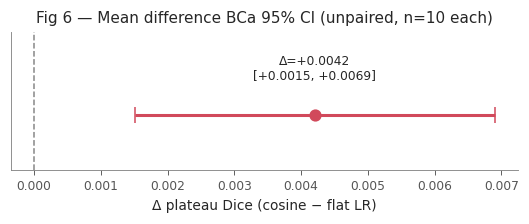

Δ=+0.0042, BCa 95% CI [+0.0015, +0.0069]


In [14]:
# BCa bootstrap CI on unpaired mean difference (cosine - flat)
from scipy.stats import norm as _norm
_obs = np.mean(cos_vals) - np.mean(flat_vals)
_rng2 = np.random.default_rng(42)
_boots = np.array([
    np.mean(_rng2.choice(cos_vals, len(cos_vals), replace=True)) -
    np.mean(_rng2.choice(flat_vals, len(flat_vals), replace=True))
    for _ in range(N_BOOT)
])
_z0 = _norm.ppf(np.mean(_boots < _obs))
_jk_a = np.array([np.mean(np.delete(cos_vals, i)) for i in range(len(cos_vals))])
_jk_b = np.array([np.mean(np.delete(flat_vals, i)) for i in range(len(flat_vals))])
_jk   = np.concatenate([_jk_a - np.mean(cos_vals), _jk_b - np.mean(flat_vals)])
_acc  = np.sum((-_jk)**3) / (6*(np.sum(_jk**2))**1.5)
_a1   = _norm.cdf(_z0 + (_z0 + _norm.ppf(0.025)) / (1 - _acc*(_z0 + _norm.ppf(0.025))))
_a2   = _norm.cdf(_z0 + (_z0 + _norm.ppf(0.975)) / (1 - _acc*(_z0 + _norm.ppf(0.975))))
_ci_lo, _ci_hi = np.percentile(_boots, 100*_a1), np.percentile(_boots, 100*_a2)

fig6, ax6 = _plt.subplots(figsize=(5, 2.2))
ax6.errorbar(_obs, 0, xerr=[[_obs - _ci_lo], [_ci_hi - _obs]],
             fmt='o', color=PALETTE[COSINE], capsize=5, markersize=7, linewidth=2)
ax6.axvline(0, color='#888888', linewidth=1, linestyle='--')
ax6.set_yticks([])
ax6.set_xlabel('Δ plateau Dice (cosine − flat LR)')
ax6.set_title(f'Fig 6 — Mean difference BCa 95% CI (unpaired, n={N} each)', fontsize=10)
ax6.text(_obs, 0.35, f'Δ={_obs:+.4f}\n[{_ci_lo:+.4f}, {_ci_hi:+.4f}]',
         ha='center', va='bottom', fontsize=8)
ax6.set_ylim(-0.6, 0.9)
fig6.tight_layout()
fig6.savefig(FIG_DIR / 'E3_fig6_cosine_vs_flat_forest.png', dpi=150)
_plt.show()
print(f'Δ={_obs:+.4f}, BCa 95% CI [{_ci_lo:+.4f}, {_ci_hi:+.4f}]')

## 5. Decision

> **Between the two decay schedules, use `cosine_annealing` (T_max = 300, η_min = 1×10⁻⁶) at `lr = 3e-4`.**

| Priority | Criterion | Cosine | Plateau | Status (n = 10) |
|---|---|---|---|---|
| 1 | **Plateau Dice — *primary*** | 0.8346 | 0.8331 | tie — Δ = +0.0015, p = 0.32, CI [−0.0006, +0.0038] spans 0 |
| 2 | Peak Dice / IoU | 0.8451 | **0.8459** | tie — Δ ≈ −0.0007 / −0.0010, p = 0.43, CI spans 0 |
| 3 | Generalisation gap | 0.096 | 0.097 | tie — p = 0.70, CI spans 0 |
| 4 | Training throughput | 119.4 sps | 118.9 sps | tie — Δ = +0.5 sps (+0.4 %), p = 0.85 |
| — | Convergence epoch *(tie-breaker)* | **125.5** | 161.0 | cosine reaches best checkpoint ≈ 36 epochs earlier |

**Rationale.** On every quality and cost axis the two schedules are statistically indistinguishable (no metric survives its family threshold; all CIs straddle 0; all |d_z| ≤ 0.38). With quality tied, the deciding factor is operational: cosine is a **deterministic, validation-independent** schedule whose LR trajectory is fully specified by epoch count, and it reaches its best checkpoint ~22 % earlier. 

**Decay-vs-no-decay (post-hoc).** A 1-seed pilot showed no quality difference between cosine and flat LR, so the scheduler was dropped before E4. Post-hoc unpaired comparison of E3 cosine (10 seeds) against E4 flat LR (10 seeds, same architecture and lr, different experiment purpose) on plateau Dice: Δ=+0.0042, BCa 95% CI [+0.0015, +0.0069] — entirely above zero (p=0.017, unpaired rank test). The 1-seed pilot was underpowered and missed this effect.

> ⚠ **The E4 decision to drop the scheduler was made on insufficient evidence.** This comparison is unpaired — E3 and E4 were separate experiments with different purposes — so the finding is indicative rather than conclusive. A dedicated paired 10-seed flat-vs-cosine experiment would confirm it. Until then, E4 onward uses flat LR (`use_lr_scheduler: false`) as a pragmatic choice that is retrospectively questionable on plateau Dice.